# Group Two — Industrial Cybersecurity Data Analysis

| Student name | ID |
|---|---:|
| Senay Teweldebrhan | 9120588 |
| Juan Camilo Chirivi | 9115141 |
| Zeynep Ozdemir | 9045142 |

This notebook analyzes industrial Internet of Things network traffic. It follows the assignment requirements by enhancing DataFrame output, examining the data, using a Python class and methods, calculating descriptive statistics, and producing the required visualizations and numerical summary.

# Data Overview

Machine Learning-Based Cyber Threat Detection in IoT and Industrial IoT Environments

IoT and IIoT environments generate large amounts of network and device data, making it difficult to distinguish normal behavior from malicious activity. Poorly selected or incomplete cybersecurity datasets can cause machine learning models to learn patterns that do not accurately represent real attacks.

### Poorly Defined Question

How can machine learning detect cyberattacks in industrial systems?

### Improved Research Question

How can machine learning models use IoT and IIoT network traffic data to identify malicious activity before it leads to significant disruption in industrial environments?

## Questions to Consider for Choosing Data

### Will it be automated?

Yes. The long-term objective would be to automate the analysis using machine learning models capable of classifying network activity as normal or malicious.

### Will it be a major decision or a minor one?

It could support major cybersecurity decisions. Detecting malicious activity in an IIoT environment may lead security teams to investigate traffic, isolate devices, block connections, or respond to a potential cyberattack.

Because false positives could also affect legitimate industrial activity, the results should support human decision-making rather than automatically triggering critical actions without validation.

### Will it be broadly implemented or implemented for one customer or interaction at a time?

The approach could be broadly implemented across an Industrial IoT network rather than being limited to a single user or device.

### Who will deploy it?

In a real environment, the solution could be deployed by cybersecurity teams, network administrators, SOC analysts, or engineers responsible for monitoring IIoT and industrial networks.

### How can we track it?

The system could be evaluated by monitoring how accurately it identifies normal and malicious network activity.

Metrics such as detection rate, false positives, false negatives, precision, recall, and model accuracy could later be used to measure performance.

## Setup and configuration

Run the following cell before running the remainder of the notebook. It imports the required libraries, identifies the project root, adds the project to Python's import path, imports the reusable class and function from `src/data_analysis.py`, and defines the dataset location.

The dataset must be saved inside the project's `data` folder. If its filename differs, update `CSV_FILE` to match the exact filename.

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Circle

try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_analysis import DataAnalyzer, enhance_dataframe_output

CSV_FILE = PROJECT_ROOT / "data" / "ML-EdgeIIoT-dataset.csv"
sns.set_theme(style="whitegrid")

## Challenge 2: Enhance the DataFrame output

The Pandas display settings are adjusted so the dataset's 63 columns can be inspected more easily. This affects only how the DataFrame appears in the notebook; it does not alter the underlying data.

In [3]:
enhance_dataframe_output(max_rows=20, max_columns=None)

DataFrame display settings updated successfully.


## Challenge 3: Understand the data

The `DataAnalyzer` class loads the CSV and provides reusable methods for examining sample records, dimensions, column names, data types, missing values, duplicate rows, attack labels, and attack types. Understanding these properties before calculation prevents inappropriate analysis and misleading conclusions.

In [4]:
analyzer = DataAnalyzer(CSV_FILE)
df = analyzer.load_data()
display(df.head(10))

Dataset loaded successfully.


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
5,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
6,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
7,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
8,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
9,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [5]:
analyzer.full_summary()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


Number of rows: 157800
Number of columns: 63
Column names:
- frame.time
- ip.src_host
- ip.dst_host
- arp.dst.proto_ipv4
- arp.opcode
- arp.hw.size
- arp.src.proto_ipv4
- icmp.checksum
- icmp.seq_le
- icmp.transmit_timestamp
- icmp.unused
- http.file_data
- http.content_length
- http.request.uri.query
- http.request.method
- http.referer
- http.request.full_uri
- http.request.version
- http.response
- http.tls_port
- tcp.ack
- tcp.ack_raw
- tcp.checksum
- tcp.connection.fin
- tcp.connection.rst
- tcp.connection.syn
- tcp.connection.synack
- tcp.dstport
- tcp.flags
- tcp.flags.ack
- tcp.len
- tcp.options
- tcp.payload
- tcp.seq
- tcp.srcport
- udp.port
- udp.stream
- udp.time_delta
- dns.qry.name
- dns.qry.name.len
- dns.qry.qu
- dns.qry.type
- dns.retransmission
- dns.retransmit_request
- dns.retransmit_request_in
- mqtt.conack.flags
- mqtt.conflag.cleansess
- mqtt.conflags
- mqtt.hdrflags
- mqtt.len
- mqtt.msg_decoded_as
- mqtt.msg
- mqtt.msgtype
- mqtt.proto_len
- mqtt.protoname
- mq

,Missing Values
frame.time,0
ip.src_host,0
ip.dst_host,0
arp.dst.proto_ipv4,0
arp.opcode,0
...,...
mbtcp.len,0
mbtcp.trans_id,0
mbtcp.unit_id,0
Attack_label,0


Number of duplicate rows: 814

Attack_label:


,Count
Attack_label,
1,133499
0,24301



Attack_type:


,Count
Attack_type,
Normal,24301
DDoS_UDP,14498
DDoS_ICMP,14090
Ransomware,10925
DDoS_HTTP,10561
SQL_injection,10311
Uploading,10269
DDoS_TCP,10247
Backdoor,10195


## Data cleansing and feature engineering

Before analysis, the dataset is checked for missing values, inconsistent formats, duplicate rows, and unusual observations. The supplied file contains no missing cells, but some columns have mixed data types and 814 rows are exact duplicates. Duplicate packet records are reported rather than automatically removed because repeated network events may be meaningful; removal would require additional domain justification.

Many protocol-specific fields legitimately contain zero. For example, an MQTT field can be zero when a record is not MQTT traffic. These zeros are therefore retained. Selected fields are converted to numeric values with `errors="coerce"`, which changes invalid text representations to missing values without stopping the notebook.

The analysis focuses on meaningful numeric network fields. `Attack_label` is treated as a categorical indicator, where `0` represents normal traffic and `1` represents attack traffic. For the Venn diagram, a TCP-membership feature is derived from whether `tcp.dstport` is greater than zero.

In [6]:
analysis_columns = [
    "tcp.dstport",
    "tcp.len",
    "tcp.checksum",
    "udp.time_delta",
    "http.content_length",
    "mqtt.len"
]

for column in analysis_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

numeric_data = df[analysis_columns]
display(numeric_data.head())

,tcp.dstport,tcp.len,tcp.checksum,udp.time_delta,http.content_length,mqtt.len
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0


## Case Overview

Industrial Internet of Things environments connect sensors, controllers, applications, and operational equipment. These connections generate network traffic that can contain both normal activity and cyberattacks. This case uses packet-level attributes and attack labels to summarize traffic behaviour, examine variation, and compare attack records with TCP traffic.

The dataset contains 157,800 records and 63 columns. `Attack_type` identifies normal traffic and 14 attack categories, while `Attack_label` provides a binary normal-or-attack classification. The analysis is descriptive: it explains the supplied sample and does not attempt to train a predictive model.

## Requirement: Using a class and methods

The reusable `DataAnalyzer` class is stored in `src/data_analysis.py`. Its constructor stores the CSV path, `load_data()` creates the DataFrame, and methods such as `display_shape()`, `display_missing_values()`, and `full_summary()` organize repeated analysis tasks. The separate `enhance_dataframe_output()` function configures Pandas display settings.

The notebook calls this external Python script through:

```python
from src.data_analysis import DataAnalyzer, enhance_dataframe_output
```

This design keeps the notebook readable and demonstrates modular, reusable Python code.

## Communication and collaboration

We use Microsoft Teams for meetings and project discussions. Project files and version history are shared through GitHub so group members can review and contribute to the work. We also use a WhatsApp group for quick updates, questions, and task coordination.

**GitHub repository:** https://github.com/tewelde05/Prog8431--26F---Sec1---Group-2

## Challenge 5: Mean, Median, and Mode

We calculate the mean, median, and mode for relevant numerical network columns. The mean describes the arithmetic average, the median identifies the middle ordered value, and the mode identifies the most frequent value. Comparing them helps reveal skewness and the influence of extreme observations.

For protocol-specific columns, a mode of zero often means that the field does not apply to most records; it does not automatically mean the data is missing or incorrect.

In [7]:
central_tendency = pd.DataFrame({
    "Mean": numeric_data.mean(),
    "Median": numeric_data.median(),
    "Mode": numeric_data.mode().iloc[0]
}).round(2)

display(central_tendency)

,Mean,Median,Mode
tcp.dstport,17964.65,1883.0,80.0
tcp.len,129.78,0.0,0.0
tcp.checksum,25796.60,23906.0,0.0
udp.time_delta,0.34,0.0,0.0
http.content_length,14.72,0.0,0.0
mqtt.len,0.42,0.0,0.0


### Use-case interpretation

This dataset is treated as a **sample** of broader industrial network activity. For `tcp.dstport`, the mean describes the average destination-port number, the median identifies the central port value, and the mode identifies the most frequently observed port. Port numbers are identifiers, so these statistics summarize traffic patterns rather than physical quantities.

## Challenge 6: Variance, Standard Deviation, and Quartiles

We calculate sample variance and sample standard deviation for relevant numerical columns to measure how widely their values are dispersed. We also calculate the minimum (Q0), first quartile (Q1), median (Q2), third quartile (Q3), and maximum (Q4).

These measures help describe network-traffic variation and identify unusually large observations. However, potential outliers are not automatically errors: extreme packet lengths, time differences, or port values may represent valid attack behavior.

In [8]:
variation_summary = pd.DataFrame({
    "Variance": numeric_data.var(ddof=1),
    "Standard Deviation": numeric_data.std(ddof=1)
}).round(2)

display(variation_summary)

,Variance,Standard Deviation
tcp.dstport,5.834265e+08,24154.22
tcp.len,1.708347e+06,1307.04
tcp.checksum,4.628105e+08,21513.03
udp.time_delta,9.382000e+01,9.69
http.content_length,5.274356e+04,229.66
mqtt.len,1.301000e+01,3.61


In [9]:
quartile_summary = numeric_data.quantile([0, 0.25, 0.50, 0.75, 1.00])
quartile_summary.index = [
    "Minimum",
    "Q1 (25%)",
    "Q2 - Median (50%)",
    "Q3 (75%)",
    "Maximum (100%)"
]
display(quartile_summary.round(2))

,tcp.dstport,tcp.len,tcp.checksum,udp.time_delta,http.content_length,mqtt.len
Minimum,0.0,0.0,0.0,0.0,0.0,0.0
Q1 (25%),80.0,0.0,2982.0,0.0,0.0,0.0
Q2 - Median (50%),1883.0,0.0,23906.0,0.0,0.0,0.0
Q3 (75%),45494.0,14.0,44733.0,0.0,0.0,0.0
Maximum (100%),65535.0,65228.0,65535.0,507.0,83655.0,39.0


### Twenty-word summary

This analysis measures network-port variation and divides destination ports into four groups to reveal typical and widely dispersed traffic patterns.

The four destination-port sections are:

- **Q1:** minimum to the 25th percentile — the lowest quarter of recorded ports.
- **Q2:** the 25th percentile to the median — the next quarter.
- **Q3:** the median to the 75th percentile — the third quarter.
- **Q4:** the 75th percentile to the maximum — the highest quarter.

Variance is expressed in squared port units, while standard deviation returns to the original port-number scale. Both show how widely destination ports vary around their mean.

## Challenge 7: Data Visualizations

### Scatter plot

The scatter plot explores the relationship between TCP destination port and TCP payload length. Points are coloured by `Attack_label` to compare normal and attack traffic. A reproducible random sample of 10,000 records is plotted for readability, while calculations continue to use the complete dataset.

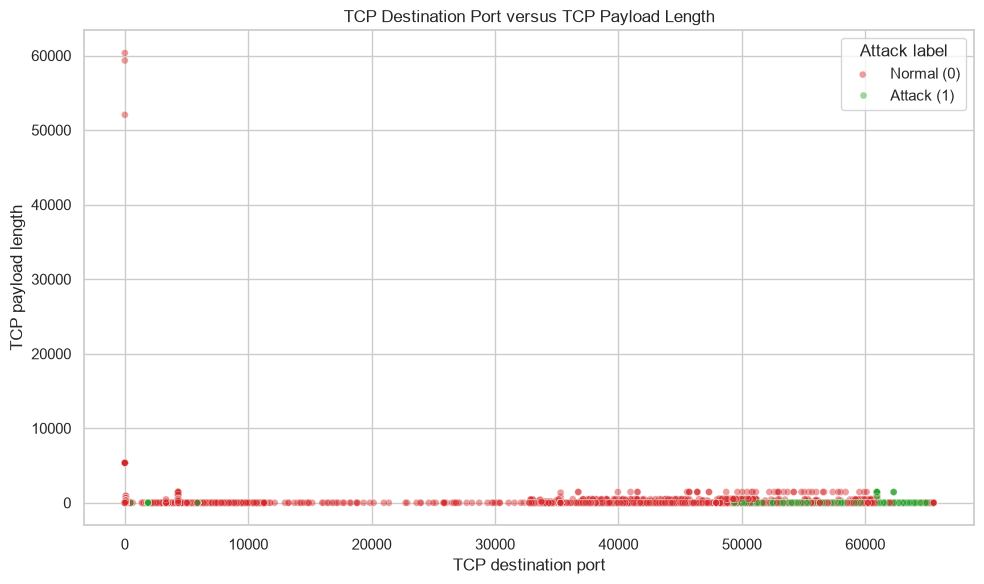

In [10]:
plot_sample = df.sample(n=min(10000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="tcp.dstport",
    y="tcp.len",
    hue="Attack_label",
    palette={0: "#2ca02c", 1: "#d62728"},
    alpha=0.45,
    s=25
)
plt.title("TCP Destination Port versus TCP Payload Length")
plt.xlabel("TCP destination port")
plt.ylabel("TCP payload length")
plt.legend(title="Attack label", labels=["Normal (0)", "Attack (1)"])
plt.tight_layout()
plt.show()

### Histogram

The histogram shows the distribution of TCP destination ports. The mean and median reference lines help reveal whether the distribution is symmetric or influenced by high-numbered ports. Peaks represent destination-port ranges that occur frequently in the captured traffic.

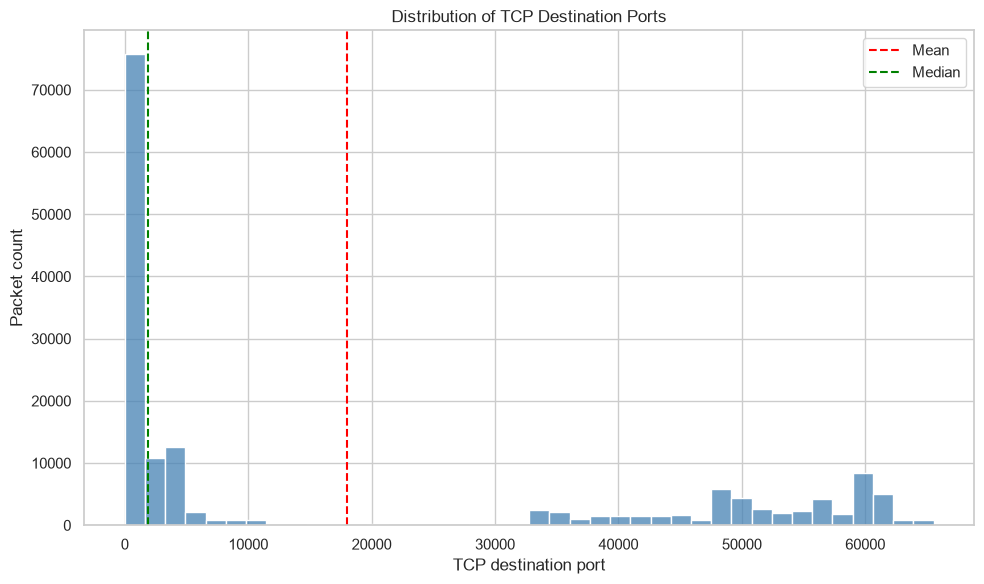

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["tcp.dstport"].dropna(), bins=40, color="steelblue", edgecolor="white")
plt.axvline(df["tcp.dstport"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["tcp.dstport"].median(), color="green", linestyle="--", label="Median")
plt.title("Distribution of TCP Destination Ports")
plt.xlabel("TCP destination port")
plt.ylabel("Packet count")
plt.legend()
plt.tight_layout()
plt.show()

### Box-and-whisker plot

The box represents the middle 50% of destination-port values, the internal line represents the median, and the whiskers show the broader non-outlier range. Points outside the whiskers are statistical outliers, but they should be investigated before being classified as errors.

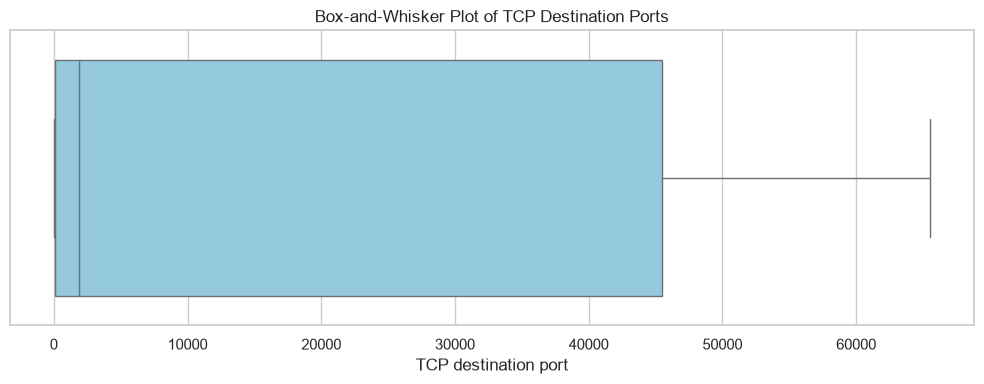

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="tcp.dstport", color="skyblue")
plt.title("Box-and-Whisker Plot of TCP Destination Ports")
plt.xlabel("TCP destination port")
plt.tight_layout()
plt.show()

### Venn diagram

The Venn diagram shows the overlap between records labelled as attacks and records identified as TCP traffic. TCP membership is defined as `tcp.dstport > 0`. The intersection therefore represents TCP records that are also labelled as attacks.

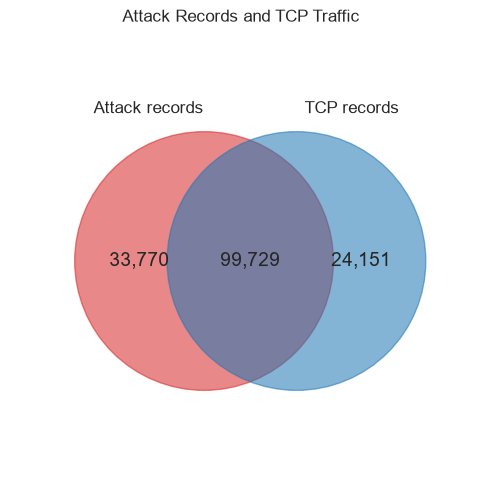

Attack only: 33770
TCP only: 24151
Attack and TCP: 99729


In [13]:
attack_records = set(df.index[df["Attack_label"] == 1])
tcp_records = set(df.index[df["tcp.dstport"] > 0])

attack_only = len(attack_records - tcp_records)
tcp_only = len(tcp_records - attack_records)
overlap = len(attack_records & tcp_records)

fig, ax = plt.subplots(figsize=(8, 6))
ax.add_patch(Circle((0.42, 0.5), 0.28, color="#d62728", alpha=0.55))
ax.add_patch(Circle((0.62, 0.5), 0.28, color="#1f77b4", alpha=0.55))
ax.text(0.28, 0.5, f"{attack_only:,}", ha="center", va="center", fontsize=14)
ax.text(0.52, 0.5, f"{overlap:,}", ha="center", va="center", fontsize=14)
ax.text(0.76, 0.5, f"{tcp_only:,}", ha="center", va="center", fontsize=14)
ax.text(0.30, 0.82, "Attack records", ha="center", fontsize=12)
ax.text(0.74, 0.82, "TCP records", ha="center", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
plt.title("Attack Records and TCP Traffic")
plt.show()

print("Attack only:", attack_only)
print("TCP only:", tcp_only)
print("Attack and TCP:", overlap)

## Challenge 8: Numerical Summary

We present the count, mean, standard deviation, variance, minimum, quartiles, maximum, and mode for the selected numerical columns. This combined table provides a compact description of the centre, spread, and range of each network measurement and highlights fields dominated by zeros or extreme values.

In [14]:
numerical_summary = numeric_data.describe().T
numerical_summary["variance"] = numeric_data.var(ddof=1)
numerical_summary["mode"] = numeric_data.mode().iloc[0]

numerical_summary = numerical_summary[[
    "count", "mean", "std", "variance", "min",
    "25%", "50%", "75%", "max", "mode"
]].round(2)

display(numerical_summary)

,count,mean,std,variance,min,25%,50%,75%,max,mode
tcp.dstport,157800.0,17964.65,24154.22,5.834265e+08,0.0,80.0,1883.0,45494.0,65535.0,80.0
tcp.len,157800.0,129.78,1307.04,1.708347e+06,0.0,0.0,0.0,14.0,65228.0,0.0
tcp.checksum,157800.0,25796.60,21513.03,4.628105e+08,0.0,2982.0,23906.0,44733.0,65535.0,0.0
udp.time_delta,157800.0,0.34,9.69,9.382000e+01,0.0,0.0,0.0,0.0,507.0,0.0
http.content_length,157800.0,14.72,229.66,5.274356e+04,0.0,0.0,0.0,0.0,83655.0,0.0
mqtt.len,157800.0,0.42,3.61,1.301000e+01,0.0,0.0,0.0,0.0,39.0,0.0


## Conclusion

The dataset is suitable for the assignment because it supports descriptive statistics, comparison of groups, and multiple visualizations. It contains substantially more attack traffic than normal traffic and represents several network protocols. The analysis also demonstrates why cybersecurity data requires careful interpretation: zero values can be valid, repeated records may represent real events, and statistical outliers may reflect attacks rather than data-quality problems.

## Sources

### Article

Ferrag, M. A., et al. (2022). Edge-IIoTset: A New Comprehensive Realistic Cyber Security Dataset of IoT and IIoT Applications for Centralized and Federated Learning. IEEE Access.

https://ieeexplore.ieee.org/document/9751703

### Dataset

ML-EdgeIIoT-dataset.csv

https://github.com/Rayan-Ali1083/Layer7Defend/blob/main/ML-EdgeIIoT-dataset.csv